## 0. Preparación (solo en Google Colab)

Esta celda no hace nada en local. En Colab clona el repositorio, entra en él e instala las dependencias con las versiones del proyecto (necesarias para que el modelo guardado sea compatible con la app).

**Si el entorno se reinicia solo** (Colab muestra que la sesión se cerró), es lo esperado la primera vez: se actualizaron librerías que ya estaban cargadas. Vuelve a ejecutar desde esta celda y continúa.

In [ ]:
import os
import subprocess
import sys
from importlib.metadata import version
from pathlib import Path

if "google.colab" in sys.modules:
    REPO_DIR = Path("/content/Chefwise")
    if not REPO_DIR.exists():
        subprocess.check_call(["git", "clone", "-q", "https://github.com/lezti02/Chefwise.git", str(REPO_DIR)])
    os.chdir(REPO_DIR)
    # Mismas versiones que requirements.txt (el modelo guardado debe poder cargarse en la app).
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pandas>=3.0,<4", "numpy>=2.4,<3",
                           "scipy>=1.17,<2", "scikit-learn>=1.9,<2", "joblib>=1.5,<2", "sentence-transformers>=6.1,<7"])
    # Si Colab ya tenía cargada una versión anterior, hay que reiniciar para usar la nueva.
    loaded = {"numpy": "numpy", "pandas": "pandas", "scipy": "scipy", "sklearn": "scikit-learn"}
    stale = [m for m, dist in loaded.items() if m in sys.modules and sys.modules[m].__version__ != version(dist)]
    if stale:
        print(f"Se actualizaron {stale}: el entorno se reinicia solo. Cuando termine, ejecuta de nuevo desde esta celda.")
        os.kill(os.getpid(), 9)

---
# 05. Comparación: TF-IDF vs. embeddings

> ⚖️ **Aquí juntamos los dos modelos.** Calificamos al **Modelo 1 (baseline, TF-IDF)** y al **Modelo 2 (embeddings)** con las mismas preguntas y la misma regla,
> y vemos si los embeddings le ganan al baseline y si vale la pena lo que cuestan.

| Sección | Qué hacemos |
| --- | --- |
| 3.1 | Cargamos el baseline que guardó el notebook 03 |
| 3.2 – 3.3 | Dejamos listas las funciones para recomendar con los dos modelos y las comprobamos |
| 3.4 | Primera prueba **a ojo**: tacos, búsquedas escritas y sinónimos |
| 3.5 – 3.6 | **Calificamos a los dos** con las 320 preguntas y comparamos las métricas |
| 3.7 | Ejemplos lado a lado |
| 3.8 | Cuánto cuesta cada modelo (tiempo, espacio) |
| 3.9 – 3.10 | Resumen automático y conclusiones |


## 3.0 Cargar el dataset del modelo

La celda funciona igual si Jupyter arranca en la carpeta del proyecto o dentro de `notebooks/`.

Antes de seguir revisamos tres cosas, para no entrenar con datos rotos:

1. que estén las columnas que vamos a usar;
2. que ninguna receta tenga el texto vacío;
3. que no haya recetas repetidas (`recipe_id` único).


In [ ]:
# --- Herramientas básicas de Python ---
import json
import sys
import time
from pathlib import Path

# --- Gráficas, datos y tablas ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data").exists():          # si estamos dentro de notebooks/, subimos un nivel
    PROJECT_DIR = PROJECT_DIR.parent
sys.path.insert(0, str(PROJECT_DIR))

# --- Código propio del proyecto (carpeta src/) ---
# emb: funciones para crear y usar embeddings.
from src import embeddings as emb
# ev: funciones para evaluar (preguntas de prueba, métricas, bootstrap).
from src import evaluation as ev
# Errores propios que avisan si falta un archivo o si no coincide con el CSV.
from src.exceptions import ArtifactMismatchError, ArtifactNotFoundError
# Funciones para cargar el baseline (TF-IDF) que guardó el notebook 03.
from src.models import load_artifacts, validate_alignment

# --- Rutas de archivos y carpetas ---
DATA_PATH = PROJECT_DIR / "data" / "processed" / "recetas_modelo.csv"
MODELS_DIR = PROJECT_DIR / "models" / "recetas_modelo"
# Copia local del modelo de lenguaje (así no hace falta internet).
EMBEDDING_MODEL_DIR = PROJECT_DIR / "models" / emb.EMBEDDING_MODEL_DIRNAME   # copia local del modelo
# Carpeta con las preguntas de prueba y los resultados.
EVAL_DIR = PROJECT_DIR / "data" / "evaluation" / "recetas_modelo"
EVAL_SET_PATH = EVAL_DIR / "eval_set.json"
# Carpeta donde se guardan las gráficas.
FIGURES_DIR = PROJECT_DIR / "notebooks" / "figures"
# Creamos las carpetas si no existen.
EVAL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Nombre del modelo de embeddings que elegimos.
EMBEDDING_MODEL_NAME = emb.EMBEDDING_MODEL_NAME
# Este modelo pide una "etiqueta" al inicio del texto:
# "query: " para lo que escribe la persona y "passage: " para las recetas.
QUERY_PREFIX, PASSAGE_PREFIX = emb.default_prefixes(EMBEDDING_MODEL_NAME)

# Opciones de cómo se muestran las tablas.
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)

# Resumen de lo que vamos a usar y con qué versiones de librerías.
print("Dataset:", DATA_PATH.relative_to(PROJECT_DIR))
print("Modelo de embeddings:", EMBEDDING_MODEL_NAME)
print("Versiones:", emb.library_versions())


Dataset: data/processed/recetas_modelo.csv
Modelo de embeddings: intfloat/multilingual-e5-small
Versiones: {'sentence_transformers': '6.1.0', 'torch': '2.14.1', 'transformers': '5.18.0', 'numpy': '2.5.3'}


In [ ]:
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data").exists():      # si estamos dentro de notebooks/, subimos un nivel
    PROJECT_DIR = PROJECT_DIR.parent
sys.path.insert(0, str(PROJECT_DIR))

# Paso 2: ruta del archivo CSV con las recetas ya limpias (lo dejó listo el notebook 02).
DATA_PATH = PROJECT_DIR / "data" / "processed" / "recetas_modelo.csv"
df = pd.read_csv(DATA_PATH)

COLUMNAS_NECESARIAS = ["recipe_id", "recipe_key", "name", "ingredients_core", "recipe_text",
                       "country", "difficulty", "total_time_min"]
faltan = [c for c in COLUMNAS_NECESARIAS if c not in df.columns]
# `assert` detiene el notebook con un mensaje claro si algo está mal. Revisamos 3 cosas:
#   1) que no falten columnas, 2) que ninguna receta tenga el texto vacío,
#   3) que no haya recetas repetidas.
assert not faltan, f"Faltan columnas: {faltan}"
assert df["recipe_text"].notna().all() and (df["recipe_text"].str.strip() != "").all(), "hay textos vacíos"
assert df["recipe_id"].is_unique, "hay recetas repetidas"

print("Archivo:", DATA_PATH.relative_to(PROJECT_DIR))
print(f"Recetas: {len(df):,} | columnas: {df.shape[1]}")


Archivo: data/processed/recetas_modelo.csv
Recetas: 28,798 | columnas: 43


In [ ]:
df = pd.read_csv(DATA_PATH)
assert df["recipe_id"].is_unique, "recipe_id debe ser único"
assert df["recipe_text"].notna().all() and (df["recipe_text"].str.strip() != "").all()

texts = df["recipe_text"].astype(str).tolist()
recipe_ids = df["recipe_id"].to_numpy()
id_to_pos = {int(r): i for i, r in enumerate(recipe_ids)}   # de recipe_id a su fila en la tabla

# `ingredients_text`: solo los ingredientes, separados por comas (como los escribiría una persona).
# Se usa en la Prueba B.
ingredients_text = df["ingredients_core"].str.replace(" | ", ", ", regex=False)
# `app_category`: marca cada receta como postre, bebida o comida según sus etiquetas.
# np.select revisa las condiciones en orden: si es postre -> "postre"; si no, si es bebida
# -> "bebida"; y si no es ninguna -> "comida".
df["app_category"] = np.select(
    [df["tag_postre"].eq(1), df["tag_bebida"].eq(1)], ["postre", "bebida"], default="comida"
)

# Mostramos un resumen y un ejemplo de cada texto.
print(f"Recetas: {len(df):,}")
print("\nEjemplo de recipe_text:\n ", texts[5][:300])
print("\nEjemplo de ingredients_text:\n ", ingredients_text.iloc[5][:300])
print("\nTipo de receta:", df["app_category"].value_counts().to_dict())


Recetas: 28,798

Ejemplo de recipe_text:
  hallacas venezolanas carne cochino vino papelon alcaparra harina de maiz aceite de onoto cebolla ajoporro cebollin pimenton rojo pimenton verde aji dulce vinagre pastilla de caldo condimento aceite semilla de onoto harina de maiz precocida agua pimenton cortado en tirita aceituna rellena cebolla en 

Ejemplo de ingredients_text:
  carne, cochino, vino, papelon, alcaparra, harina de maiz, aceite de onoto, cebolla, ajoporro, cebollin, pimenton rojo, pimenton verde, aji dulce, vinagre, pastilla de caldo, condimento, aceite, semilla de onoto, harina de maiz precocida, agua, pimenton cortado en tirita, aceituna rellena, cebolla en

Tipo de receta: {'comida': 22236, 'postre': 5393, 'bebida': 1169}


### 3.0.1 Las preguntas de prueba

Se crean una sola vez y se guardan. Si el archivo ya existe y corresponde a este dataset, se **carga** (así el baseline y los embeddings
siempre se califican con las mismas preguntas). Después medimos cuántas listas de ingredientes de la Prueba B todavía "dicen" el tipo de plato
(por ejemplo, "tortilla para tacos") y calculamos qué nota sacaría alguien que recomienda **al azar**: esa es la referencia mínima.


In [30]:
# Si ya hay un conjunto de preguntas guardado, lo cargamos (así los dos modelos usan siempre las mismas).
if EVAL_SET_PATH.exists():
    eval_set = ev.load_eval_set(EVAL_SET_PATH)
    # Si fue creado con otra versión del dataset, ya no sirve: lo volvemos a crear.
    if eval_set.dataset_rows != len(df):
        print("El conjunto guardado es de otra versión del dataset: se vuelve a crear.")
        eval_set = None
else:
    eval_set = None

# Si no hay conjunto (o no sirve), lo creamos y lo guardamos.
if eval_set is None:
    eval_set = ev.build_eval_set(df)
    ev.save_eval_set(eval_set, EVAL_SET_PATH)
    print("Conjunto de evaluación CREADO en", EVAL_SET_PATH.relative_to(PROJECT_DIR))
else:
    print("Conjunto de evaluación CARGADO desde", EVAL_SET_PATH.relative_to(PROJECT_DIR))

# Revisamos que todas las preguntas existan en el dataset.
assert all(rid in id_to_pos for rid, _ in eval_set.queries)
N_QUERIES = len(eval_set.queries)
print(f"Preguntas: {N_QUERIES} | tipos de plato: {len(eval_set.groups)} | preguntas por tipo: {eval_set.queries_per_group}")

# Tabla con cuántas recetas tiene cada tipo de plato.
resumen_tipos = (
    pd.DataFrame({"tipo de plato": list(eval_set.groups),
                  "recetas de ese tipo": [len(v) for v in eval_set.groups.values()]})
    .sort_values("recetas de ese tipo", ascending=False)
    .reset_index(drop=True)
)
display(resumen_tipos)


Conjunto de evaluación CARGADO desde data/evaluation/recetas_modelo/eval_set.json
Preguntas: 320 | tipos de plato: 32 | preguntas por tipo: 10


,tipo de plato,recetas de ese tipo
0,pasta,1277
1,ensalada,1240
2,pastel_tarta,1146
3,sopa_caldo,866
4,dip_salsa,698
5,empanadas,312
6,galletas,307
7,helado,279
8,pizza,278
9,gelatina,260


In [31]:
# Prueba B: ¿cuántas listas de ingredientes todavía "dicen" el tipo de plato? (por ejemplo, "tortilla para tacos")
# Para cada pregunta: ¿el texto de sus ingredientes contiene el nombre del tipo de plato
# (por ejemplo, "tortilla para tacos")? Guarda True o False.
leak = [
    bool(ev.family_pattern(group).search(ev.normalize_text(ingredients_text.iloc[id_to_pos[rid]])))
    for rid, group in eval_set.queries
]
# El promedio de una lista de True/False es el porcentaje de True.
print(f"Prueba B: {np.mean(leak):.1%} de las listas de ingredientes menciona su tipo de plato "
      f"(en la prueba A, el 100 % lo trae en el nombre).")

# Referencia: qué calificación sacaría alguien que recomienda al azar
# `ev.random_baseline` calcula qué nota sacaría recomendar recetas totalmente al azar.
RANDOM_BASELINE = ev.random_baseline(eval_set, len(df))
print("\nCalificación esperada al azar:", {k: round(v, 4) for k, v in RANDOM_BASELINE.items()})


Prueba B: 13.8% de las listas de ingredientes menciona su tipo de plato (en la prueba A, el 100 % lo trae en el nombre).

Calificación esperada al azar: {'Precision@5': 0.0105, 'Recall@5': 0.0002, 'HitRate@5': 0.0502, 'NDCG@5': 0.0105, 'Precision@10': 0.0105, 'Recall@10': 0.0003, 'HitRate@10': 0.0951, 'NDCG@10': 0.0105}


In [32]:
# Si existe la copia local del modelo, la usamos; si no, se descargaría de Hugging Face (internet, ~470 MB).
modelo_origen = EMBEDDING_MODEL_DIR if EMBEDDING_MODEL_DIR.is_dir() else EMBEDDING_MODEL_NAME
print("Cargando el modelo desde:", modelo_origen)
# Cargamos el modelo de lenguaje en memoria.
model = emb.load_embedding_model(modelo_origen)

# Datos básicos del modelo: cuántos números da por texto, cuánto texto lee
# y en qué dispositivo corre (CPU o tarjeta gráfica).
print("Números por texto (dimensión):", emb.embedding_dimension(model))
print("Texto máximo que lee (tokens):", model.max_seq_length)
print("Dónde corre:", model.device)
print("Prefijos -> persona:", repr(QUERY_PREFIX), "| receta:", repr(PASSAGE_PREFIX))


Cargando el modelo desde: /Users/i./Documents/DIPLOMADO/MODULO_5/chefWise/models/embedding_model


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Números por texto (dimensión): 384
Texto máximo que lee (tokens): 512
Dónde corre: mps:0
Prefijos -> persona: 'query: ' | receta: 'passage: '


In [33]:
# Cargamos los embeddings que guardó el notebook 04 (solo sirven si corresponden al texto actual).
emb_art = emb.load_embedding_artifacts(
    MODELS_DIR, texts=texts, expected_model_name=EMBEDDING_MODEL_NAME, load_model=False
)
# Le pegamos el modelo cargado al objeto, para poder convertir textos nuevos más adelante.
emb_art.model = model

# `meta`: datos del cálculo (modelo usado, tiempo, dispositivo...).
# `E`: la tabla de embeddings (una fila por receta, 384 números cada una).
meta = emb_art.metadata
E = emb_art.matrix
print("Embeddings CARGADOS (no se recalcularon).")
print(f"\nTabla de embeddings: {E.shape[0]:,} recetas x {E.shape[1]} números")
print(f"Memoria: {E.nbytes / 1e6:.1f} MB")
print(f"Tiempo para calcularla: {meta['build_seconds']} s en '{meta['device']}'")


Embeddings CARGADOS (no se recalcularon).

Tabla de embeddings: 28,798 recetas x 384 números
Memoria: 44.2 MB
Tiempo para calcularla: 25.82 s en 'mps:0'


## 3.1 Modelo 1 (baseline, TF-IDF): se carga tal cual lo dejó el notebook 03

Leemos los archivos de `models/recetas_modelo/` (los que guardó el notebook 03) y comprobamos que corresponden a este CSV.
**No se cambia nada del baseline.**

Para saber **cuánto tarda en armarse** TF-IDF, lo volvemos a construir en memoria con los mismos ajustes del notebook 03
y comprobamos que sale idéntico. Esa copia no se guarda.


In [34]:
# Cargamos el baseline tal como lo guardó el notebook 03 (`m1` = Modelo 1).
m1 = load_artifacts(MODELS_DIR)
# Comprobamos que el modelo guardado corresponde exactamente a este CSV.
validate_alignment(m1, texts)
# El vectorizador TF-IDF y la matriz con los números de cada receta.
tfidf, tfidf_matrix = m1.vectorizer, m1.matrix
print(f"TF-IDF cargado: {tfidf_matrix.shape[0]:,} recetas x {tfidf_matrix.shape[1]:,} palabras")

# Mostramos los ajustes con los que se creó el TF-IDF.
ajustes = {k: tfidf.get_params()[k] for k in ("lowercase", "strip_accents", "ngram_range", "min_df", "max_df", "sublinear_tf")}
print("Ajustes:", ajustes)

# Medimos cuánto tarda armar TF-IDF desde cero con esos mismos ajustes (esta copia NO se guarda).
t0 = time.perf_counter()
copia = TfidfVectorizer(**ajustes)
copia_matrix = copia.fit_transform(texts)
TFIDF_BUILD_SECONDS = time.perf_counter() - t0

# Comprobamos que la copia sale idéntica a la guardada.
assert copia.vocabulary_ == tfidf.vocabulary_ and abs(copia_matrix - tfidf_matrix).max() < 1e-9
print(f"\nTiempo para armar TF-IDF: {TFIDF_BUILD_SECONDS:.2f} s (y sale idéntico al guardado)")
# Borramos la copia para liberar memoria.
del copia, copia_matrix


TF-IDF cargado: 28,798 recetas x 5,436 palabras
Ajustes: {'lowercase': True, 'strip_accents': 'unicode', 'ngram_range': (1, 1), 'min_df': 2, 'max_df': 0.5, 'sublinear_tf': True}

Tiempo para armar TF-IDF: 0.18 s (y sale idéntico al guardado)


## 3.2 Las funciones para recomendar

Las mismas dos funciones, una vez con cada modelo:

| Función | Qué hace | Modelo |
| --- | --- | --- |
| `recomendar_similares(recipe_id)` | receta → las más parecidas | Embeddings |
| `recomendar_por_texto(texto)` | ingredientes escritos → recetas | Embeddings |
| `recomendar_similares_tfidf(recipe_id)` | receta → las más parecidas | TF-IDF (baseline) |
| `recomendar_por_texto_tfidf(texto)` | ingredientes escritos → recetas | TF-IDF (baseline) |

> Aquí `recomendar_similares` / `recomendar_por_texto` son de **embeddings**. El baseline lleva el sufijo `_tfidf`.

Se compara **una** receta contra todas (nunca todas contra todas)
y la receta de partida no se recomienda a sí misma.


In [35]:
# Columnas que mostramos en cada recomendación.
RESULT_COLUMNS = ["recipe_id", "name", "country", "difficulty", "total_time_min"]


# Ordena de más a menos parecida y se queda con las n primeras.
# (Estas tres funciones son de EMBEDDINGS.)
def _top_n(similitudes, n, excluir=None):
    """Ordena de más a menos parecida. La receta en la posición `excluir` no entra."""
    # Copia de las similitudes como números decimales.
    sims = np.asarray(similitudes, dtype=np.float64).copy()
    # La receta de partida no se recomienda a sí misma: su similitud pasa a -infinito.
    if excluir is not None:
        sims[excluir] = -np.inf
    # Ordenamos de mayor a menor parecido y tomamos las n primeras.
    mejores = np.argsort(-sims, kind="stable")[:n]
    # Tabla con los datos de las recetas elegidas + su similitud.
    resultado = df.iloc[mejores][RESULT_COLUMNS].copy()
    resultado["similitud"] = np.asarray(similitudes)[mejores].round(3)
    return resultado.reset_index(drop=True)


# Auxiliar: pasa de recipe_id a fila de la tabla (con error claro si no existe).
def _posicion(recipe_id):
    if recipe_id not in id_to_pos:
        raise ValueError(f"No existe recipe_id={recipe_id}")
    return id_to_pos[recipe_id]


# Auxiliar: revisa que el texto escrito no esté vacío.
def _revisar_texto(texto):
    if not isinstance(texto, str) or not texto.strip():
        raise ValueError("Escribe al menos una palabra.")


# ---------------- Modelo 2: embeddings ----------------
# EMBEDDINGS, receta -> las más parecidas (se compara la fila de embeddings de esa receta contra todas).
def recomendar_similares(recipe_id, n=10):
    pos = _posicion(recipe_id)
    return _top_n(emb_art.similarities_to_row(pos), n, excluir=pos)


# EMBEDDINGS, texto escrito -> las más parecidas (el texto se convierte en embedding y se compara contra todas).
def recomendar_por_texto(texto, n=10):
    _revisar_texto(texto)
    return _top_n(emb_art.similarities(texto), n)


# ---------------- Modelo 1: TF-IDF ----------------
# TF-IDF (baseline), receta -> las más parecidas.
# Multiplicar las matrices equivale a la similitud coseno porque TF-IDF ya viene normalizado.
def recomendar_similares_tfidf(recipe_id, n=10):
    pos = _posicion(recipe_id)
    return _top_n((tfidf_matrix @ tfidf_matrix[pos].T).toarray().ravel(), n, excluir=pos)


# TF-IDF (baseline), texto escrito -> las más parecidas.
def recomendar_por_texto_tfidf(texto, n=10):
    _revisar_texto(texto)
    return _top_n(m1.similarities(texto), n)


## 3.3 Dos comprobaciones rápidas

1. Nuestro cálculo rápido da **lo mismo** que la función `cosine_similarity` de scikit-learn (la que se usó en el notebook 03).
2. Los embeddings guardados **corresponden al CSV**: si volvemos a pasar unas recetas por el modelo, sale el mismo resultado.


In [36]:
# Buscamos la misma receta de tacos que usó el notebook 03.
es_tacos = df["name"].str.contains(r"\btacos?\b", case=False) & df["country"].eq("México")
EJEMPLO_ID = int(df.loc[es_tacos, "recipe_id"].iloc[0])     # la misma receta de ejemplo que el notebook 03
pos_ej = id_to_pos[EJEMPLO_ID]

# (1) el cálculo rápido coincide con scikit-learn
# Comprobación 1: nuestro cálculo rápido debe dar lo mismo que `cosine_similarity` de scikit-learn.
ref_tfidf = cosine_similarity(tfidf_matrix[pos_ej], tfidf_matrix).ravel()
ref_emb = cosine_similarity(E[pos_ej:pos_ej + 1], E).ravel()
assert np.allclose(ref_tfidf, (tfidf_matrix @ tfidf_matrix[pos_ej].T).toarray().ravel(), atol=1e-6)
assert np.allclose(ref_emb, emb_art.similarities_to_row(pos_ej), atol=1e-5)
print("(1) Cálculo rápido = scikit-learn: OK")

# (2) los embeddings guardados corresponden al CSV
# Comprobación 2: tomamos 5 recetas repartidas por todo el CSV, volvemos a calcular su embedding
# y lo comparamos con el guardado.
muestra = np.linspace(0, len(df) - 1, 5).astype(int)
nuevos = emb.encode_texts(model, [texts[i] for i in muestra], prefix=meta["passage_prefix"])
# Si el CSV hubiera cambiado, aquí saltaría un error.
assert np.abs(nuevos - E[muestra]).max() < 1e-3
print("(2) Embeddings alineados con el CSV: OK")


(1) Cálculo rápido = scikit-learn: OK
(2) Embeddings alineados con el CSV: OK


## 3.4 Primera prueba (a ojo)

### 3.4.1 La misma receta del notebook 03

Ponemos lado a lado lo que sugiere cada modelo para la misma receta de tacos.


In [37]:
# Mostramos la receta de partida...
print("Receta de partida:", df.loc[pos_ej, "name"], "|", df.loc[pos_ej, "country"])
print("\n=== Modelo 1 - TF-IDF ===")
# ...y las 10 recomendaciones de cada modelo, una tabla debajo de la otra.
display(recomendar_similares_tfidf(EJEMPLO_ID, n=10))
print("=== Modelo 2 - Embeddings ===")
display(recomendar_similares(EJEMPLO_ID, n=10))


Receta de partida: Tacos de Cerdo con Salsa Roja | México

=== Modelo 1 - TF-IDF ===


,recipe_id,name,country,difficulty,total_time_min,similitud
0,32,Burrito de Cerdo con Salsa Roja Ahumada,España,intermedio,45.0,0.484
1,10999,Huevo con Tortilla,México,facil,15.0,0.395
2,6061,Sopitos,México,intermedio,75.0,0.387
3,6362,Tacos de Filete con Tocino,México,facil,20.0,0.386
4,7964,Tacos de Camaron y Pulpo,México,intermedio,45.0,0.386
5,10176,Chorizo con Huevo en Salsa Roja,México,facil,30.0,0.381
6,8709,Chicharron en Salsa Roja,México,facil,40.0,0.378
7,1370,Chuletas de Cerdo en Salsa de Chipotle,México,facil,30.0,0.378
8,5950,Tacos Ahogados de Pollo con Salsa Roja,México,facil,35.0,0.373
9,7637,Tacos para Crudos Fresas,México,intermedio,90.0,0.373


=== Modelo 2 - Embeddings ===


,recipe_id,name,country,difficulty,total_time_min,similitud
0,6294,Cerdo en Salsa Verde en Tacos de Tortilla de Maíz,México,reto,120.0,0.953
1,5130,Tacos de Milanesa,México,facil,90.0,0.947
2,6362,Tacos de Filete con Tocino,México,facil,20.0,0.946
3,7964,Tacos de Camaron y Pulpo,México,intermedio,45.0,0.946
4,3822,Tacos Enchilados de Carnitas,México,facil,270.0,0.945
5,6454,Tacos Ahogados,México,facil,40.0,0.945
6,231,Tacos al Pastor,México,facil,45.0,0.944
7,37,Tacos de Carnitas,México,intermedio,90.0,0.943
8,14,Tacos de Carne Molida,México,facil,30.0,0.943
9,4537,Receta de Tacos Norteños,México,facil,40.0,0.943


### 3.4.2 Buscar escribiendo ("con lo que tengo")

Probamos una lista de ingredientes y una frase normal, como la escribiría una persona.


In [38]:
# Probamos dos consultas: una lista de ingredientes y una frase normal.
for consulta in ["pollo jitomate chile", "algo dulce con chocolate para el postre"]:
    print(f"########  Consulta: {consulta!r}")
    print("--- Modelo 1 - TF-IDF ---")
    # `[[...]]` elige solo algunas columnas para que la tabla sea más corta.
    display(recomendar_por_texto_tfidf(consulta, n=8)[["recipe_id", "name", "country", "similitud"]])
    print("--- Modelo 2 - Embeddings ---")
    display(recomendar_por_texto(consulta, n=8)[["recipe_id", "name", "country", "similitud"]])


########  Consulta: 'pollo jitomate chile'
--- Modelo 1 - TF-IDF ---


,recipe_id,name,country,similitud
0,15029,Pollo con Chipotle,México,0.569
1,12236,Pollo en Salsa de Jitomate,México,0.557
2,6965,Pollo en Salsa de Chile Guajillo,México,0.550
3,10889,Salsa de Tomate Verde con Jitomate,México,0.527
4,6331,Salsa Roja,México,0.524
5,13908,Pollo con Salsa de Ajonjolí,México,0.518
6,9611,Pollo en Estofado en Jitomate,México,0.510
7,9177,Chiles Rellenos de Pollo en Salsa de Tomate,México,0.508


--- Modelo 2 - Embeddings ---


,recipe_id,name,country,similitud
0,9177,Chiles Rellenos de Pollo en Salsa de Tomate,México,0.883
1,14229,Chile Relleno de Queso Bañado en Salsa de Jitomate Roja,México,0.882
2,10829,Chile Relleno con Queso,México,0.882
3,6525,Mixiote de Pollo Express,México,0.882
4,15029,Pollo con Chipotle,México,0.880
5,12204,Pollo a los 3 Chiles,México,0.880
6,9204,Pollo con Chile Piquin,México,0.878
7,5268,Tostitos de Tinga,México,0.878


########  Consulta: 'algo dulce con chocolate para el postre'
--- Modelo 1 - TF-IDF ---


,recipe_id,name,country,similitud
0,12960,Mousse de Chocolate con el Robot de Cocina,España,0.325
1,20843,Blanquitos para Golosos con el Robot de Cocina,España,0.318
2,18586,Cobertura de Chocolate con el Robot de Cocina,España,0.310
3,16277,Mousse de Chocolate Casero,Internacional,0.301
4,18098,Trufas de Chocolate sin Nata,España,0.300
5,17174,Sirope de Chocolate con el Robot de Cocina,España,0.295
6,18648,Salsa de Chocolate Blanco con el Robot de Cocina,España,0.283
7,20389,Helado de Chocolate con el Robot de Cocina,España,0.279


--- Modelo 2 - Embeddings ---


,recipe_id,name,country,similitud
0,949,Pastel de Chocolate Humedo y Esponjoso,España,0.894
1,13320,Brownie de Chocolate y Fresa sin Gluten,Internacional,0.892
2,13591,Pastel para los Amantes del Chocolate,México,0.891
3,13725,Chocolatines de Frutos Rojos,México,0.888
4,2610,Turron de Chocolate Blanco con Galletas de Chocolate Rel...,España,0.888
5,141,Pastel de Chocolate con Fresas y Crema Batida,Internacional,0.886
6,10500,Helado de Pistache y Chocolate,México,0.885
7,8708,Pastel de Chocolate y Café,México,0.885


### 3.4.3 ¿Entienden sinónimos?

Comparamos pares de palabras o frases con los dos modelos. Esto **no cuenta** para la calificación; solo muestra la diferencia:

* En TF-IDF, si dos textos **no comparten ninguna palabra**, el parecido es exactamente 0 (aunque signifiquen lo mismo).
* En embeddings los números siempre salen altos. Para leerlos, compáralos con el parecido de **dos recetas al azar**
  (última línea): lo que importa es cuánto se separa cada par de ese valor.


In [39]:
# Pares de palabras o frases que significan casi lo mismo (y un par que no tiene nada que ver, al final).
pairs = [
    ("jitomate", "tomate"), ("frijoles", "alubias"), ("papa", "patata"),
    ("tacos de pollo", "quesadillas de pollo"), ("sopa de lentejas", "guiso de legumbres"),
    ("pastel de chocolate", "brownie"), ("pollo asado", "pastel de chocolate"),
]


# Parecido entre dos textos con TF-IDF.
def _sim_tfidf(a, b):
    # Convertimos los dos textos en números TF-IDF.
    va, vb = tfidf.transform([a, b])
    # `@` multiplica las filas: es la similitud coseno.
    return float((va @ vb.T).toarray()[0, 0])


# Parecido entre dos textos con embeddings.
def _sim_emb(a, b):
    # Convertimos los dos textos en embeddings.
    va, vb = emb.encode_texts(model, [a, b], prefix=PASSAGE_PREFIX)
    return float(va @ vb)


# Referencia: parecido promedio entre 2000 pares de RECETAS al azar
# (semilla 0 = siempre salen los mismos pares).
rng = np.random.default_rng(0)
random_pairs = rng.integers(0, len(df), size=(2000, 2))
# Parecido de cada par al azar con TF-IDF...
rand_tfidf = np.asarray(tfidf_matrix[random_pairs[:, 0]].multiply(tfidf_matrix[random_pairs[:, 1]]).sum(axis=1)).ravel()
# ...y con embeddings.
rand_emb = (E[random_pairs[:, 0]] * E[random_pairs[:, 1]]).sum(axis=1)

# Tabla final: para cada par, el parecido según cada modelo.
demo = pd.DataFrame(
    [(a, b, _sim_tfidf(a, b), _sim_emb(a, b)) for a, b in pairs],
    columns=["frase A", "frase B", "coseno TF-IDF", "coseno embeddings"],
).round(3)
display(demo)
print(f"Similitud media entre 2000 pares de RECETAS al azar -> TF-IDF: {rand_tfidf.mean():.3f} | embeddings: {rand_emb.mean():.3f}")


,frase A,frase B,coseno TF-IDF,coseno embeddings
0,jitomate,tomate,0.000,0.933
1,frijoles,alubias,0.000,0.883
2,papa,patata,0.000,0.912
3,tacos de pollo,quesadillas de pollo,0.199,0.960
4,sopa de lentejas,guiso de legumbres,0.000,0.928
5,pastel de chocolate,brownie,0.000,0.857
6,pollo asado,pastel de chocolate,0.000,0.890


Similitud media entre 2000 pares de RECETAS al azar -> TF-IDF: 0.041 | embeddings: 0.895


## 3.5 Calificar a los dos modelos

Las **preguntas de prueba**, la **regla de acierto** y las **métricas** son las mismas que definió el notebook 03.
Ahora calificamos a los **dos modelos** en las cuatro combinaciones:

| | Prueba A (receta completa) | Prueba B (solo ingredientes) |
| --- | --- | --- |
| **Baseline (TF-IDF)** | ✔ | ✔ |
| **Embeddings** | ✔ | ✔ |

Esta celda vuelve a calificar al baseline, ahora junto a embeddings, para tener los dos en la misma tabla.


In [40]:
rankings = {}   # (modelo, protocolo) -> {recipe_id: top-10 ids}, para el análisis cualitativo


# `tracked` envuelve una función de similitud y, de paso, guarda el Top-10 de cada pregunta
# (se usa más abajo en los ejemplos lado a lado).
def tracked(fn, store):
    def wrapper(rid, pos):
        sims = fn(rid, pos)
        store[rid] = ev.top_k_ids(sims, recipe_ids, 10, exclude_pos=pos)
        return sims
    return wrapper


# Cuatro combinaciones (modelo, prueba). Cada función recibe (recipe_id, fila)
# y devuelve el parecido contra TODAS las recetas.
similarity_fns = {
    # Prueba A: se parte de la receta completa.
    ("TF-IDF", "A"): lambda rid, pos: (tfidf_matrix @ tfidf_matrix[pos].T).toarray().ravel(),
    ("Embeddings", "A"): lambda rid, pos: emb_art.similarities_to_row(pos),
    # Prueba B: se parte solo de los ingredientes escritos como texto.
    ("TF-IDF", "B"): lambda rid, pos: m1.similarities(ingredients_text.iloc[pos]),
    ("Embeddings", "B"): lambda rid, pos: emb_art.similarities(ingredients_text.iloc[pos]),
}

# Calificamos cada combinación sobre las MISMAS preguntas.
results = {}
for key, fn in similarity_fns.items():
    rankings[key] = {}
    results[key] = ev.evaluate(eval_set, tracked(fn, rankings[key]), recipe_ids, id_to_pos)

# Las dos tablas parten de EXACTAMENTE las mismas consultas, en el mismo orden
# Comprobación: las dos tablas de cada prueba parten de las mismas preguntas, en el mismo orden.
for protocol in ("A", "B"):
    assert results[("TF-IDF", protocol)]["recipe_id"].tolist() == results[("Embeddings", protocol)]["recipe_id"].tolist()
print("Preguntas evaluadas por modelo y prueba:", {f"{m}/{p}": len(r) for (m, p), r in results.items()})


Preguntas evaluadas por modelo y prueba: {'TF-IDF/A': 320, 'Embeddings/A': 320, 'TF-IDF/B': 320, 'Embeddings/B': 320}


## 3.6 Resultados: baseline vs. embeddings


In [41]:
# Orden en que mostramos las métricas y nombre de cada prueba.
ORDER = ["Precision@5", "Precision@10", "Recall@5", "Recall@10", "HitRate@5", "HitRate@10", "NDCG@5", "NDCG@10"]
PROTOCOL_NAMES = {"A": "Prueba A - receta completa", "B": "Prueba B - solo ingredientes"}


# Arma una tabla con una fila por modelo (TF-IDF, Embeddings y Azar) para una prueba.
def comparison_table(protocol):
    rows = {
        "TF-IDF": results[("TF-IDF", protocol)][ORDER].mean(),
        "Embeddings": results[("Embeddings", protocol)][ORDER].mean(),
        "Azar (referencia)": pd.Series(RANDOM_BASELINE)[ORDER],
    }
    table = pd.DataFrame(rows).T
    table.index.name = "Modelo"
    return table


# Una tabla para la prueba A y otra para la B.
tables = {p: comparison_table(p) for p in ("A", "B")}
# Mostramos las dos tablas.
for p in ("A", "B"):
    print(f"### {PROTOCOL_NAMES[p]}  ({len(results[('TF-IDF', p)])} preguntas)")
    display(tables[p].round(4))


### Prueba A - receta completa  (320 preguntas)


,Precision@5,Precision@10,Recall@5,Recall@10,HitRate@5,HitRate@10,NDCG@5,NDCG@10
Modelo,,,,,,,,
TF-IDF,0.4975,0.4750,0.0171,0.0317,0.8500,0.9312,0.5123,0.4920
Embeddings,0.5956,0.5522,0.0193,0.0348,0.9188,0.9625,0.6123,0.5763
Azar (referencia),0.0105,0.0105,0.0002,0.0003,0.0502,0.0951,0.0105,0.0105


### Prueba B - solo ingredientes  (320 preguntas)


,Precision@5,Precision@10,Recall@5,Recall@10,HitRate@5,HitRate@10,NDCG@5,NDCG@10
Modelo,,,,,,,,
TF-IDF,0.2487,0.2312,0.0075,0.0135,0.5812,0.6906,0.2557,0.2414
Embeddings,0.2488,0.2213,0.0076,0.0131,0.5312,0.6469,0.2600,0.2367
Azar (referencia),0.0105,0.0105,0.0002,0.0003,0.0502,0.0951,0.0105,0.0105


### 3.6.1 ¿La diferencia es real o pura suerte?

Si un modelo saca 0.62 y el otro 0.60, puede ser casualidad de las preguntas que tocaron.
Para saberlo usamos un truco llamado **bootstrap**:

1. Sorteamos 10,000 veces un conjunto de preguntas (con repetición) a partir de las que tenemos.
2. En cada sorteo calculamos la diferencia entre los dos modelos.
3. Nos quedamos con el rango donde cae el 95 % de esas diferencias (**intervalo al 95 %**).

**Cómo leerlo:** si el intervalo queda **todo arriba de 0**, embeddings es mejor de verdad.
Si queda **todo abajo de 0**, TF-IDF (el baseline) es mejor. Si **cruza el 0**, no hay diferencia clara.


In [42]:
# Para cada prueba y cada métrica comparamos los dos modelos con bootstrap (ver explicación arriba).
delta_rows = []
for p in ("A", "B"):
    for metric in ORDER:
        # `a`: nota de TF-IDF en cada pregunta. `b`: nota de Embeddings en las mismas preguntas.
        a = results[("TF-IDF", p)][metric].to_numpy()
        b = results[("Embeddings", p)][metric].to_numpy()
        # Devuelve la diferencia promedio y su intervalo al 95 %.
        mean_diff, low, high = ev.paired_bootstrap(a, b)
        delta_rows.append({
            "Prueba": p, "Métrica": metric,
            "TF-IDF": a.mean(), "Embeddings": b.mean(),
            "Δ abs (Emb − TF-IDF)": mean_diff,
            "Δ relativa": mean_diff / a.mean() if a.mean() else np.nan,
            "IC95% bajo": low, "IC95% alto": high,
            # Veredicto: intervalo todo arriba de 0 -> gana Embeddings; todo abajo -> gana TF-IDF; si cruza el 0 -> sin diferencia clara.
            "Veredicto": "Embeddings mejor" if low > 0 else ("TF-IDF mejor" if high < 0 else "sin diferencia clara"),
        })
delta = pd.DataFrame(delta_rows)
# Mostramos la tabla (la diferencia relativa se ve como porcentaje).
display(delta.round(4).style.format({"Δ relativa": "{:+.1%}"}))


,Prueba,Métrica,TF-IDF,Embeddings,Δ abs (Emb − TF-IDF),Δ relativa,IC95% bajo,IC95% alto,Veredicto
0,A,Precision@5,0.497500,0.595600,0.098100,+19.7%,0.064400,0.131900,Embeddings mejor
1,A,Precision@10,0.475000,0.552200,0.077200,+16.2%,0.048100,0.105900,Embeddings mejor
2,A,Recall@5,0.017100,0.019300,0.002200,+12.8%,0.000700,0.003700,Embeddings mejor
3,A,Recall@10,0.031700,0.034800,0.003100,+9.7%,0.000600,0.005600,Embeddings mejor
4,A,HitRate@5,0.850000,0.918800,0.068800,+8.1%,0.025000,0.115600,Embeddings mejor
5,A,HitRate@10,0.931200,0.962500,0.031200,+3.4%,0.000000,0.065600,sin diferencia clara
6,A,NDCG@5,0.512300,0.612300,0.100000,+19.5%,0.066200,0.133500,Embeddings mejor
7,A,NDCG@10,0.492000,0.576300,0.084300,+17.1%,0.056000,0.112900,Embeddings mejor
8,B,Precision@5,0.248700,0.248800,-0.000000,-0.0%,-0.026900,0.027500,sin diferencia clara
9,B,Precision@10,0.231200,0.221300,-0.010000,-4.3%,-0.031600,0.011600,sin diferencia clara


### 3.6.2 Prueba B sin las preguntas "con pista"

En algunas preguntas de la prueba B, los ingredientes todavía dicen el tipo de plato ("tortilla para tacos").
Repetimos la comparación **solo con las preguntas que no tienen esa pista**, para ver si la conclusión cambia.


In [43]:
# Marcamos qué preguntas tienen "pista" (True) y cuáles no (False).
leak_mask = np.array(leak)
rows = []
# Mismo cálculo de antes, pero solo con las preguntas SIN pista.
for metric in ORDER:
    # `~leak_mask` es lo contrario de `leak_mask`: deja solo las preguntas sin pista.
    a = results[("TF-IDF", "B")][metric].to_numpy()[~leak_mask]
    b = results[("Embeddings", "B")][metric].to_numpy()[~leak_mask]
    mean_diff, low, high = ev.paired_bootstrap(a, b)
    rows.append({"Métrica": metric, "TF-IDF": a.mean(), "Embeddings": b.mean(), "Δ abs (Emb − TF-IDF)": mean_diff,
                 "IC95% bajo": low, "IC95% alto": high,
                 "Veredicto": "Embeddings mejor" if low > 0 else ("TF-IDF mejor" if high < 0 else "sin diferencia clara")})
delta_noleak = pd.DataFrame(rows)
print(f"Prueba B sin pista: {int((~leak_mask).sum())} de {len(leak_mask)} preguntas")
display(delta_noleak.round(4))


Prueba B sin pista: 276 de 320 preguntas


,Métrica,TF-IDF,Embeddings,Δ abs (Emb − TF-IDF),IC95% bajo,IC95% alto,Veredicto
0,Precision@5,0.2174,0.1942,-0.0232,-0.0493,0.0036,sin diferencia clara
1,Precision@10,0.2000,0.1703,-0.0297,-0.0507,-0.0091,TF-IDF mejor
2,Recall@5,0.0072,0.0067,-0.0006,-0.0016,0.0006,sin diferencia clara
3,Recall@10,0.0126,0.0113,-0.0013,-0.0028,0.0003,sin diferencia clara
4,HitRate@5,0.5543,0.4891,-0.0652,-0.1232,-0.0036,TF-IDF mejor
5,HitRate@10,0.6630,0.6051,-0.0580,-0.1159,0.0000,sin diferencia clara
6,NDCG@5,0.2240,0.2059,-0.0181,-0.0450,0.0091,sin diferencia clara
7,NDCG@10,0.2098,0.1848,-0.0249,-0.0464,-0.0038,TF-IDF mejor


### 3.6.3 Gráfica de las métricas

Barras azules = baseline (TF-IDF), naranjas = embeddings, raya negra = recomendar al azar.


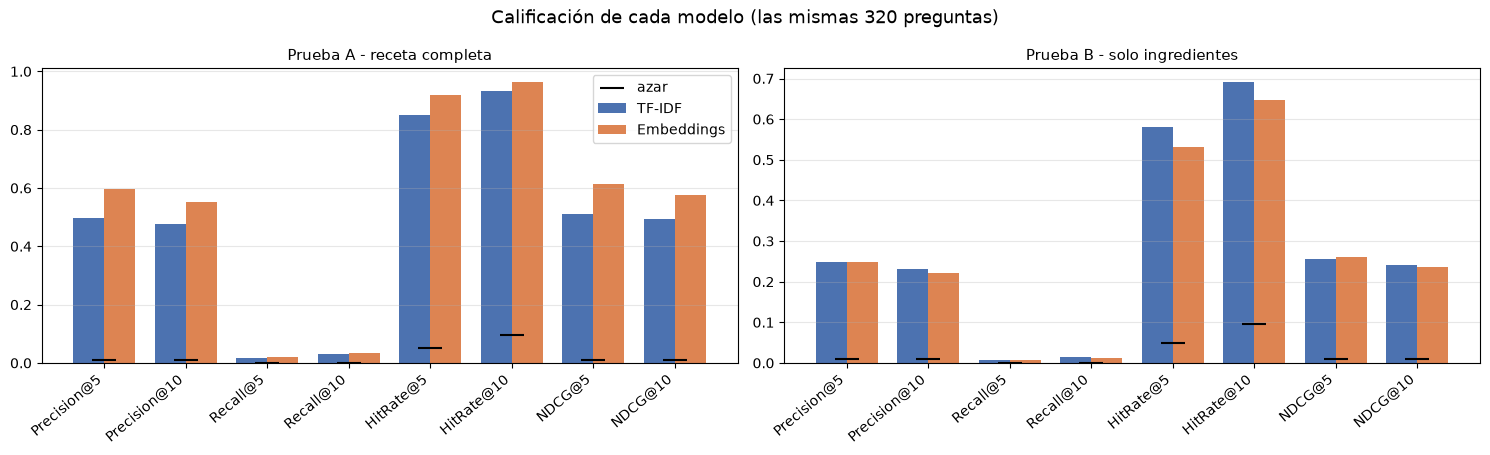

In [ ]:
# Gráfica con dos paneles: Prueba A (izquierda) y Prueba B (derecha).
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), sharey=False)
# Ancho de cada barra y posición de cada grupo de barras (una por métrica).
width = 0.38
x = np.arange(len(ORDER))
# Dibujamos cada panel: barras azules = TF-IDF, naranjas = Embeddings, raya negra = azar.
for ax, p in zip(axes, ("A", "B")):
    t = tables[p]
    ax.bar(x - width / 2, t.loc["TF-IDF"], width, label="TF-IDF", color="#4C72B0")
    ax.bar(x + width / 2, t.loc["Embeddings"], width, label="Embeddings", color="#DD8452")
    ax.scatter(x, t.loc["Azar (referencia)"], color="k", marker="_", s=300, label="azar", zorder=3)
    ax.set_xticks(x, ORDER, rotation=40, ha="right")
    ax.set_title(PROTOCOL_NAMES[p].split(":")[0], fontsize=11)
    ax.grid(axis="y", alpha=0.3)
axes[0].legend()
fig.suptitle(f"Calificación de cada modelo (las mismas {N_QUERIES} preguntas)", fontsize=13)
fig.tight_layout()
plt.show()


### 3.6.4 Por tipo de plato (NDCG@10)

Un promedio puede esconder cosas: un modelo puede ganar mucho en tacos y perder en sopas.
Aquí vemos la calificación de cada tipo de plato por separado (el notebook 03 ya midió el baseline por tipo de plato).


,TF-IDF A,Embeddings A,TF-IDF B,Embeddings B,Δ A (Emb−TF),Δ B (Emb−TF)
group,,,,,,
croquetas,0.772,0.842,0.410,0.177,0.070,-0.233
albondigas,0.510,0.682,0.260,0.124,0.172,-0.136
ceviche,0.658,0.877,0.286,0.161,0.219,-0.125
mermelada,0.459,0.563,0.136,0.021,0.104,-0.116
sandwich,0.470,0.514,0.316,0.227,0.044,-0.088
enchiladas,0.542,0.771,0.251,0.166,0.229,-0.085
pastel_tarta,0.598,0.635,0.354,0.281,0.037,-0.073
ensalada,0.491,0.737,0.384,0.332,0.246,-0.051
empanadas,0.372,0.521,0.228,0.177,0.149,-0.051


Tipos de plato donde gana Embeddings -> prueba A: 25 de 32 | prueba B: 14 de 32


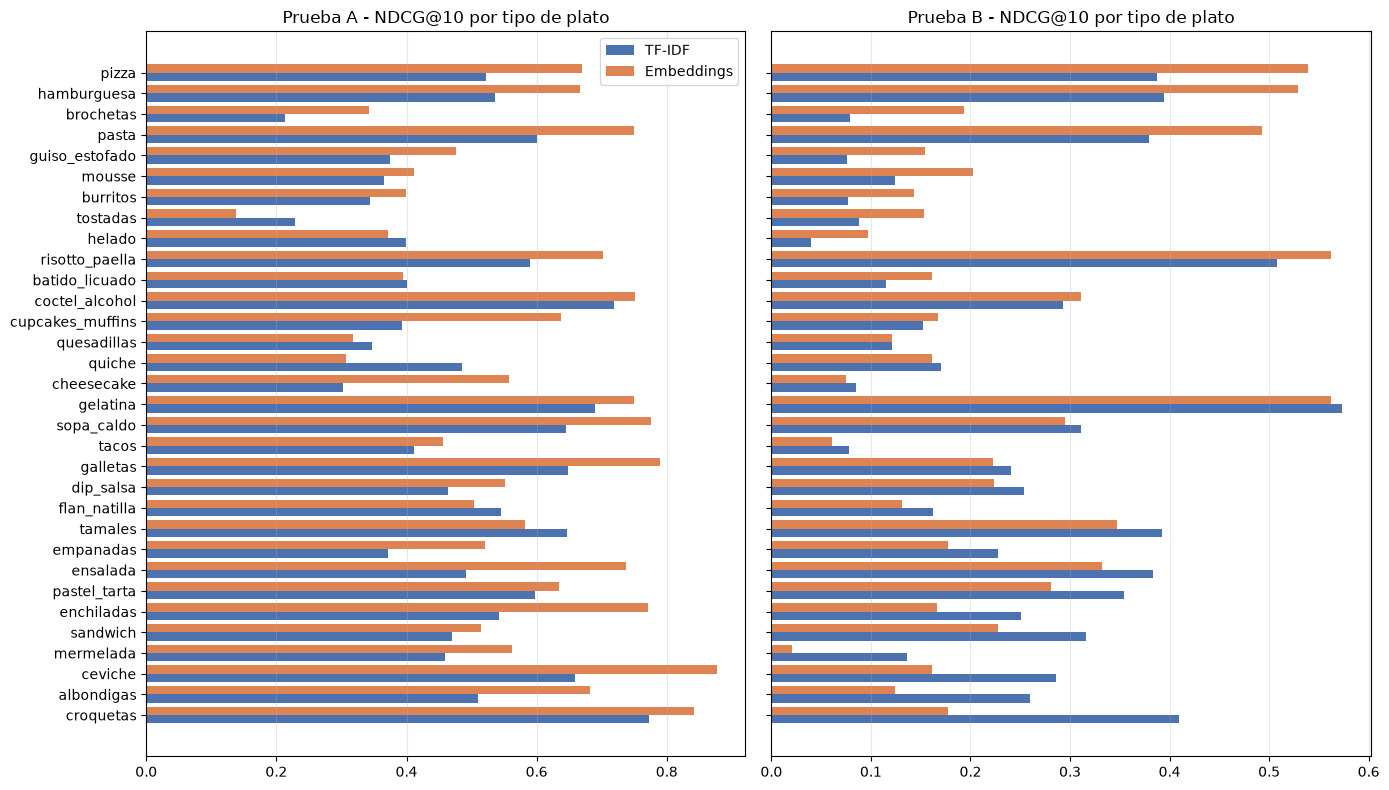

In [ ]:
# NDCG@10 promedio de cada modelo en cada tipo de plato, para las dos pruebas.
by_group = []
for p in ("A", "B"):
    for model_name in ("TF-IDF", "Embeddings"):
        # Promedio de NDCG@10 por tipo de plato.
        s = results[(model_name, p)].groupby("group")["NDCG@10"].mean().rename(f"{model_name} {p}")
        by_group.append(s)
by_group = pd.concat(by_group, axis=1)
# Diferencia (Embeddings − TF-IDF): si es positiva, gana Embeddings.
by_group["Δ A (Emb−TF)"] = by_group["Embeddings A"] - by_group["TF-IDF A"]
by_group["Δ B (Emb−TF)"] = by_group["Embeddings B"] - by_group["TF-IDF B"]
# Ordenamos de donde más pierde Embeddings (arriba) a donde más gana (abajo), según la prueba B.
by_group = by_group.sort_values("Δ B (Emb−TF)")
display(by_group.round(3))

# En cuántos tipos de plato gana Embeddings en cada prueba.
print("Tipos de plato donde gana Embeddings -> prueba A:", int((by_group['Δ A (Emb−TF)'] > 0).sum()),
      "de", len(by_group), "| prueba B:", int((by_group['Δ B (Emb−TF)'] > 0).sum()), "de", len(by_group))

# Gráfica de barras horizontales: una barra por tipo de plato y por modelo.
fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
y = np.arange(len(by_group))
for ax, p in zip(axes, ("A", "B")):
    ax.barh(y - 0.2, by_group[f"TF-IDF {p}"], 0.4, label="TF-IDF", color="#4C72B0")
    ax.barh(y + 0.2, by_group[f"Embeddings {p}"], 0.4, label="Embeddings", color="#DD8452")
    ax.set_title(f"Prueba {p} - NDCG@10 por tipo de plato")
    ax.grid(axis="x", alpha=0.3)
axes[0].set_yticks(y, by_group.index)
axes[0].legend()
fig.tight_layout()
plt.show()


### 3.6.5 Guardar los resultados

Guardamos las tablas de resultados para poder consultarlas sin volver a correr todo.


In [46]:
# Guardamos las tablas de resultados para poder consultarlas sin volver a correr todo
# Guardamos las tablas de resultados en archivos CSV para consultarlas sin volver a correr todo.
out_dir = EVAL_DIR
for p in ("A", "B"):
    tables[p].round(6).to_csv(out_dir / f"metrics_protocol_{p}.csv")
delta.round(6).to_csv(out_dir / "metrics_delta_bootstrap.csv", index=False)
delta_noleak.round(6).to_csv(out_dir / "metrics_delta_protocol_B_sin_fuga.csv", index=False)
# Tabla con el resultado de CADA pregunta, de cada modelo y prueba (sirve para análisis posteriores).
per_query = pd.concat(
    [r.assign(modelo=m, protocolo=p) for (m, p), r in results.items()], ignore_index=True
)
per_query.to_csv(out_dir / "metrics_per_query.csv", index=False)
print("Resultados guardados en", out_dir.relative_to(PROJECT_DIR), "->", sorted(f.name for f in out_dir.iterdir()))


Resultados guardados en data/evaluation/recetas_modelo -> ['computational_comparison.csv', 'eval_set.json', 'metrics_baseline_por_tipo.csv', 'metrics_baseline_protocol_A.csv', 'metrics_baseline_protocol_B.csv', 'metrics_delta_bootstrap.csv', 'metrics_delta_protocol_B_sin_fuga.csv', 'metrics_per_query.csv', 'metrics_protocol_A.csv', 'metrics_protocol_B.csv']


## 3.7 Ejemplos lado a lado

Para no escoger a mano los ejemplos que "se ven bonitos", usamos una regla fija:

* **Coinciden:** la pregunta donde los dos modelos recomiendan casi lo mismo.
* **Gana TF-IDF:** donde el baseline saca más aciertos que embeddings.
* **Gana Embeddings:** al revés.

**✓** = mismo tipo de plato (acierto). **–** = no cuenta como acierto, **pero no siempre es mala sugerencia**
(unas enchiladas para unos tacos no cuentan, aunque se parecen). Estas tablas son para entender; **lo que decide son las métricas**.


In [47]:
# Tipo de plato de cada receta del catálogo (o None si no es de ninguno de los 32 tipos).
all_groups = ev.assign_groups(df)                                   # tipo de plato de cada receta (o None)
recipe_group = dict(zip(df["recipe_id"], all_groups))
# Diccionario recipe_id -> nombre de la receta.
names = dict(zip(df["recipe_id"], df["name"]))


# Jaccard: va de 0 a 1 y dice qué tanto coinciden dos listas (recetas en común / recetas distintas en total).
def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b)


# Para cada pregunta: ¿cuánto coinciden el Top-10 de TF-IDF y el de Embeddings?
overlap = {}
for p in ("A", "B"):
    overlap[p] = pd.Series(
        {rid: jaccard(rankings[("TF-IDF", p)][rid], rankings[("Embeddings", p)][rid]) for rid, _ in eval_set.queries}
    )
    print(f"Prueba {p}: recetas en común entre los dos Top-10 (Jaccard, 0 a 1) = {overlap[p].mean():.3f}"
          f" | preguntas con el mismo Top-10: {(overlap[p] == 1).sum()} | sin ninguna en común: {(overlap[p] == 0).sum()}")


# Elige 3 casos con una regla fija (sin escoger a mano): donde coinciden, donde gana TF-IDF y donde gana Embeddings.
def pick_cases(p):
    t = results[("TF-IDF", p)].set_index("recipe_id")
    e = results[("Embeddings", p)].set_index("recipe_id")
    # Diferencia de Precision@10 (y de NDCG@10 para desempatar) entre los dos modelos en cada pregunta.
    diff = (e["Precision@10"] - t["Precision@10"]).to_frame("d1").join((e["NDCG@10"] - t["NDCG@10"]).rename("d2"))
    # Ordenamos: arriba donde más gana TF-IDF, abajo donde más gana Embeddings.
    ranked = diff.sort_values(["d1", "d2"])
    return {
        "coinciden": int(overlap[p].sort_values(ascending=False).index[0]),
        "TF-IDF más relevante": int(ranked.index[0]),
        "Embeddings más relevante": int(ranked.index[-1]),
    }


# Muestra, lado a lado, el Top-10 de cada modelo.
# ✓ = acierto (mismo tipo de plato), – = no cuenta como acierto.
def side_by_side(recipe_id, p, n=10):
    # Tipo de plato de la pregunta y conjunto de recetas que cuentan como acierto.
    group = dict(eval_set.queries)[recipe_id]
    relevant = eval_set.relevant_for(recipe_id, group)
    cols = {}
    # Para cada modelo: su Top-10 con ✓ o – delante de cada receta.
    for model_name in ("TF-IDF", "Embeddings"):
        ids_ = rankings[(model_name, p)][recipe_id][:n]
        cols[model_name] = [
            f"{'✓' if rid in relevant else '–'} {names[rid]} [{recipe_group.get(rid) or 'otro'}]" for rid in ids_
        ]
    t = results[("TF-IDF", p)].set_index("recipe_id").loc[recipe_id]
    e = results[("Embeddings", p)].set_index("recipe_id").loc[recipe_id]
    print(f"RECETA DE PARTIDA: {names[recipe_id]}  (recipe_id={recipe_id}, tipo='{group}', {len(relevant)} relevantes)")
    if p == "B":
        print("   pregunta (solo ingredientes):", ingredients_text.iloc[id_to_pos[recipe_id]][:160], "...")
    print(f"   Precision@10: TF-IDF={t['Precision@10']:.1f}  Embeddings={e['Precision@10']:.1f}   |   "
          f"NDCG@10: TF-IDF={t['NDCG@10']:.3f}  Embeddings={e['NDCG@10']:.3f}   |   Jaccard Top-10={overlap[p][recipe_id]:.2f}")
    out = pd.DataFrame(cols, index=range(1, n + 1))
    out.index.name = "rank"
    display(out)


Prueba A: recetas en común entre los dos Top-10 (Jaccard, 0 a 1) = 0.221 | preguntas con el mismo Top-10: 0 | sin ninguna en común: 20
Prueba B: recetas en común entre los dos Top-10 (Jaccard, 0 a 1) = 0.160 | preguntas con el mismo Top-10: 0 | sin ninguna en común: 27


In [48]:
# Casos de la prueba A (elegidos con la regla fija).
cases_A = pick_cases("A")
print("Casos elegidos (prueba A):", cases_A, "\n")
for label, rid in cases_A.items():
    print(f"=================  A - {label.upper()}  =================")
    side_by_side(rid, "A")


Casos elegidos (prueba A): {'coinciden': 16446, 'TF-IDF más relevante': 16326, 'Embeddings más relevante': 19623} 

=================  A - COINCIDEN  =================
RECETA DE PARTIDA: Margarita Patria  (recipe_id=16446, tipo='coctel_alcohol', 93 relevantes)
   Precision@10: TF-IDF=1.0  Embeddings=1.0   |   NDCG@10: TF-IDF=1.000  Embeddings=1.000   |   Jaccard Top-10=0.82


,TF-IDF,Embeddings
rank,,
1,✓ Receta de Margarita Clásica [coctel_alcohol],✓ Margarita Picante [coctel_alcohol]
2,✓ Margarita Picante [coctel_alcohol],✓ Margarita Clasica [coctel_alcohol]
3,✓ Margarita con Cerveza [coctel_alcohol],✓ Margarita de Piña y Coco [coctel_alcohol]
4,✓ Margarita Clasica [coctel_alcohol],✓ Margarita con Cerveza [coctel_alcohol]
5,✓ Coctel Margarita [coctel_alcohol],✓ Receta de Margarita Clásica [coctel_alcohol]
6,✓ Margarita de Limón [coctel_alcohol],✓ Coctel Margarita [coctel_alcohol]
7,✓ Margarita de Tamarindo [coctel_alcohol],✓ Margarita Picosita [coctel_alcohol]
8,✓ Margarita de Piña [coctel_alcohol],✓ Coctel Margarita Refrescante [coctel_alcohol]
9,✓ Coctel Margarita Refrescante [coctel_alcohol],✓ Margarita de Limón [coctel_alcohol]


=================  A - TF-IDF MÁS RELEVANTE  =================
RECETA DE PARTIDA: Tacos de Crema  (recipe_id=16326, tipo='tacos', 251 relevantes)
   Precision@10: TF-IDF=0.9  Embeddings=0.1   |   NDCG@10: TF-IDF=0.905  Embeddings=0.078   |   Jaccard Top-10=0.05


,TF-IDF,Embeddings
rank,,
1,✓ Tacos de Pollo al Ajillo [tacos],– Taquitos Dorados [otro]
2,✓ Deliciosos Tacos de Pollo [tacos],– Quesadillas de Tinga de Pollo [quesadillas]
3,✓ Tacos Enchilados [tacos],– Pechugas de Pollo Fáciles [otro]
4,– Tortilla de Pollo [otro],– Flautas de Pollo Mexicanas [otro]
5,✓ Tacos de Pollo y Espinaca [tacos],– Pechuga de Pollo en Leche [otro]
6,✓ Tacos Ahogados de Pollo con Salsa Roja [tacos],✓ Tacos Enchilados [tacos]
7,✓ Tacos de Pollo Desmenuzado [tacos],– Chilaquiles con Mole [otro]
8,✓ Tacos Dorados de Pollo con Salsa de Aguacate [tacos],– Receta de Tinga de Pollo [otro]
9,✓ Tacos con Pollo y Espinacas [tacos],– Pechuga de Pollo al Limón [otro]


=================  A - EMBEDDINGS MÁS RELEVANTE  =================
RECETA DE PARTIDA: Ceviche de Merluza  (recipe_id=19623, tipo='ceviche', 194 relevantes)
   Precision@10: TF-IDF=0.1  Embeddings=1.0   |   NDCG@10: TF-IDF=0.139  Embeddings=1.000   |   Jaccard Top-10=0.05


,TF-IDF,Embeddings
rank,,
1,– Merluza a la Plancha [otro],✓ Ceviche de Tilapia y Maiz Tostado [ceviche]
2,✓ Ceviche de Camaron y Merluza [ceviche],✓ Ceviche de Camaron y Merluza [ceviche]
3,– Merluza a la Cazuela [otro],✓ Ceviche de Lubina [ceviche]
4,– Merluza en Salsa de Zanahoria [otro],✓ Ceviche de Tilapia Paso a Paso [ceviche]
5,– Merluza Gitana [otro],✓ Ceviche de Calamares [ceviche]
6,– Merluza al Microondas con Limon [otro],✓ Ceviche Clasico [ceviche]
7,– Merluza a la Cazuela con Leche de Coco [otro],✓ Ceviche [ceviche]
8,– Merluza al Limon [otro],✓ Ceviche de Aguacate [ceviche]
9,– Pimientos Rellenos de Merluza [otro],✓ Ceviche de Robalo [ceviche]


In [49]:
# Casos de la prueba B (elegidos con la regla fija).
cases_B = pick_cases("B")
print("Casos elegidos (prueba B):", cases_B, "\n")
for label, rid in cases_B.items():
    print(f"=================  B - {label.upper()}  =================")
    side_by_side(rid, "B")


Casos elegidos (prueba B): {'coinciden': 375, 'TF-IDF más relevante': 8685, 'Embeddings más relevante': 25803} 

=================  B - COINCIDEN  =================
RECETA DE PARTIDA: Tamales en Salsa Verde  (recipe_id=375, tipo='tamales', 81 relevantes)
   pregunta (solo ingredientes): harina de maiz, fondo de verdura, manteca vegetal, polvo para hornear, sal, chile serrano, tomate verde, cebolla, ajo, cilantro, comino, pechuga de pollo, aceit ...
   Precision@10: TF-IDF=0.7  Embeddings=0.7   |   NDCG@10: TF-IDF=0.779  Embeddings=0.643   |   Jaccard Top-10=0.67


,TF-IDF,Embeddings
rank,,
1,✓ Tamales de Rajas [tamales],– Tamal Horneado [otro]
2,✓ Tamales Vegetarianos [tamales],✓ Pastel de Tamales [tamales]
3,✓ Pastel de Tamales [tamales],✓ Tamales Verdes [tamales]
4,✓ Tamales Suizos [tamales],✓ Tamales Sencillos [tamales]
5,✓ Tamales de Chicharrón en Salsa Verde [tamales],✓ Tamales Verdes con Pollo [tamales]
6,– Rosca de Tamal [otro],✓ Tamales Suizos [tamales]
7,– Tamal Verde [otro],– Tamal Verde [otro]
8,– Tamal Horneado [otro],✓ Tamales de Chicharrón en Salsa Verde [tamales]
9,✓ Tamales de Rajas con Pollo [tamales],✓ Tamales de Rajas [tamales]


=================  B - TF-IDF MÁS RELEVANTE  =================
RECETA DE PARTIDA: Croquetas de Pollo Desmenuzado  (recipe_id=8685, tipo='croquetas', 219 relevantes)
   pregunta (solo ingredientes): pollo, puerro, cebolla, zanahoria, leche, mantequilla, harina, sal, nuez moscada, huevo batido, pan rallado ...
   Precision@10: TF-IDF=0.9  Embeddings=0.2   |   NDCG@10: TF-IDF=0.915  Embeddings=0.145   |   Jaccard Top-10=0.05


,TF-IDF,Embeddings
rank,,
1,✓ Croquetas de Jamon y Queso Fritas [croquetas],– Budin de Zanahoria Salado [otro]
2,✓ Croquetas sin Huevo [croquetas],– Bocaditos de Patata Souffle [otro]
3,✓ Croquetas de Huevo Duro [croquetas],– Budin de Puerros [otro]
4,✓ Croquetas de Pollo Asado [croquetas],– Puerros Rellenos en Salsa de Mostaza y Queso [otro]
5,– Tarta de Cebolla y Puerro [otro],– Canelones de Verduras [pasta]
6,✓ Croquetas de Pollo y Huevo Duro [croquetas],✓ Croquetas de Huevo Duro [croquetas]
7,✓ Croquetas de Gambas [croquetas],– Pastel de Fideos [pasta]
8,✓ Croquetas de Pollo Caseras Paso a Paso [croquetas],– Puerros Gratinados al Horno [otro]
9,✓ Croquetas de Jamon con el Robot de Cocina [croquetas],✓ Croquetas de Zanahorias y Coco [croquetas]


=================  B - EMBEDDINGS MÁS RELEVANTE  =================
RECETA DE PARTIDA: Pizza de Roquefort  (recipe_id=25803, tipo='pizza', 277 relevantes)
   pregunta (solo ingredientes): unid masa para pizza, unid tomate de lata, unid cebolla, aceite, queso roquefort, oregano, aji molido ...
   Precision@10: TF-IDF=0.1  Embeddings=0.8   |   NDCG@10: TF-IDF=0.064  Embeddings=0.827   |   Jaccard Top-10=0.11


,TF-IDF,Embeddings
rank,,
1,– Tortilla de Papa y Cebolla [otro],✓ Papas Pizza [pizza]
2,– Masa para Tallarines [pasta],✓ Pizza Campesina [pizza]
3,– Tortilla de Pollo y Papa [otro],✓ Pizza de Mozzarella al Roquefort [pizza]
4,– Tallarines al Pimiento [pasta],– Tortilla de Papa y Cebolla [otro]
5,– Enchiladas Verdes al Horno [enchiladas],✓ Pizza de Cebolla y Atun [pizza]
6,– Aji de Huevos [otro],– Calzone de Verduras [otro]
7,– Ensalada de Pollo y Apio [ensalada],✓ Pizza Aran-Ita [pizza]
8,– Arroz con Mollejas [otro],✓ Pizza Carbonara [pizza]
9,– Guiso de Pescado [guiso_estofado],✓ Pizza de Atún Mediterránea [pizza]


## 3.8 ¿Cuánto cuesta cada modelo?

Medimos en esta misma computadora:

* **Armar el modelo:** cuánto tarda en convertir las ~29 mil recetas en números.
* **Espacio:** cuánto ocupan los archivos.
* **Responder:** cuánto tarda en dar un Top-10, en dos casos:
  * **receta → Top-10:** la receta ya está convertida; solo hay que comparar y ordenar.
  * **texto → Top-10:** primero hay que convertir lo que escribió la persona (en embeddings eso significa pasar el texto por el modelo).



In [50]:
# Mide cuánto tarda `funcion` con cada argumento y devuelve la mediana en milisegundos
# (la mediana no se deja engañar por una corrida lenta aislada).
def mediana_ms(funcion, argumentos):
    """Mediana, en milisegundos, de lo que tarda `funcion` con cada argumento."""
    tiempos = []
    for a in argumentos:
        t0 = time.perf_counter()
        funcion(a)
        tiempos.append((time.perf_counter() - t0) * 1000)
    return float(np.median(tiempos))


# Escogemos 200 recetas al azar (siempre las mismas) para medir tiempos; 60 se usan como textos escritos.
rng = np.random.default_rng(0)
posiciones = rng.choice(len(df), size=200, replace=False)
textos_prueba = ingredients_text.iloc[posiciones[:60]].tolist()

# Cargamos una copia del modelo de embeddings forzada a CPU (lo normal en un servidor barato, sin tarjeta gráfica).
cpu_model = emb.load_embedding_model(modelo_origen, device="cpu")
emb_cpu = emb.EmbeddingArtifacts(matrix=E, metadata=meta, model=cpu_model)

# Una vuelta de calentamiento para que la primera llamada no cuente.
recomendar_similares(EJEMPLO_ID); recomendar_por_texto("pollo"); emb_cpu.similarities("pollo")
recomendar_similares_tfidf(EJEMPLO_ID); recomendar_por_texto_tfidf("pollo")

# Medimos el tiempo de cada modelo en dos casos: receta -> Top-10 y texto -> Top-10.
tiempos = {
    "TF-IDF": {
        "receta": mediana_ms(lambda p: ev.top_k_ids((tfidf_matrix @ tfidf_matrix[p].T).toarray().ravel(), recipe_ids, 10, p), posiciones),
        "texto": mediana_ms(lambda t: ev.top_k_ids(m1.similarities(t), recipe_ids, 10), textos_prueba),
    },
    "Embeddings": {
        "receta": mediana_ms(lambda p: ev.top_k_ids(emb_art.similarities_to_row(p), recipe_ids, 10, p), posiciones),
        "texto": mediana_ms(lambda t: ev.top_k_ids(emb_art.similarities(t), recipe_ids, 10), textos_prueba),
        "texto_cpu": mediana_ms(lambda t: ev.top_k_ids(emb_cpu.similarities(t), recipe_ids, 10), textos_prueba),
    },
}

# Cuánto tardaría armar los embeddings en CPU: medimos 512 recetas y multiplicamos (es una estimación).
t0 = time.perf_counter()
emb.encode_texts(cpu_model, texts[:512], prefix=PASSAGE_PREFIX)
EMB_BUILD_CPU_ESTIMATE_S = (time.perf_counter() - t0) / 512 * len(texts)
# Liberamos memoria.
del cpu_model, emb_cpu
print("Tiempos medidos (ms):", {m: {k: round(v, 2) for k, v in d.items()} for m, d in tiempos.items()})


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Tiempos medidos (ms): {'TF-IDF': {'receta': 3.36, 'texto': 2.93}, 'Embeddings': {'receta': 2.14, 'texto': 9.66, 'texto_cpu': 10.64}}


In [51]:
# Devuelve el tamaño de un archivo (o carpeta completa) en MB, como texto.
def megas(ruta):
    ruta = Path(ruta)
    total = ruta.stat().st_size if ruta.is_file() else sum(f.stat().st_size for f in ruta.rglob("*") if f.is_file())
    return f"{total / 1e6:,.1f} MB"


# Atajos: `t` = tiempos de TF-IDF, `e` = tiempos de Embeddings.
t, e = tiempos["TF-IDF"], tiempos["Embeddings"]
# Tabla comparativa de costos: una columna por modelo y una fila por cada cosa que medimos.
costos = pd.DataFrame(
    {
        "TF-IDF": [
            f"{tfidf_matrix.shape[1]:,} palabras (casi todas en cero)",
            f"{TFIDF_BUILD_SECONDS:.1f} s en CPU",
            f"matriz {megas(MODELS_DIR / 'recipe_tfidf_matrix.joblib')} + vectorizador {megas(MODELS_DIR / 'tfidf_vectorizer.joblib')}",
            "no",
            f"{t['receta']:.1f} ms",
            f"{t['texto']:.1f} ms",
        ],
        "Embeddings": [
            f"{E.shape[1]} números (todos con valor)",
            f"{meta['build_seconds']:.0f} s en '{meta['device']}' | ~{EMB_BUILD_CPU_ESTIMATE_S:.0f} s en CPU (estimado)",
            f"matriz {megas(MODELS_DIR / emb.EMBEDDINGS_FILENAME)}",
            f"sí: {megas(EMBEDDING_MODEL_DIR)}" if EMBEDDING_MODEL_DIR.is_dir() else "sí (~470 MB)",
            f"{e['receta']:.1f} ms",
            f"{e['texto']:.1f} ms en '{model.device}' | {e['texto_cpu']:.1f} ms en CPU",
        ],
    },
    index=["Tamaño de cada receta", "Tiempo para armarlo", "Archivos", "Necesita un modelo externo",
           "Receta → Top-10 (mediana)", "Texto → Top-10 (mediana)"],
)
costos.index.name = "Qué se mide"
# Mostramos la tabla sin cortar el texto de las celdas.
with pd.option_context("display.max_colwidth", None):
    display(costos)
# La guardamos como CSV.
costos.to_csv(EVAL_DIR / "computational_comparison.csv")


,TF-IDF,Embeddings
Qué se mide,,
Tamaño de cada receta,"5,436 palabras (casi todas en cero)",384 números (todos con valor)
Tiempo para armarlo,0.2 s en CPU,26 s en 'mps:0' | ~131 s en CPU (estimado)
Archivos,matriz 6.1 MB + vectorizador 0.1 MB,matriz 44.2 MB
Necesita un modelo externo,no,sí: 488.2 MB
Receta → Top-10 (mediana),3.4 ms,2.1 ms
Texto → Top-10 (mediana),2.9 ms,9.7 ms en 'mps:0' | 10.6 ms en CPU


## 3.9 Resumen 



In [52]:
# Resumen automático: no hay números escritos a mano, todo sale de las tablas calculadas arriba.
for p in ("A", "B"):
    # Filas de la comparación bootstrap de esta prueba.
    d = delta[delta["Prueba"] == p]
    print(f"===== {PROTOCOL_NAMES[p]}")
    # Por cada veredicto, listamos las métricas que cayeron en él con su diferencia.
    for veredicto in ("Embeddings mejor", "TF-IDF mejor", "sin diferencia clara"):
        sub = d[d["Veredicto"] == veredicto]
        txt = ", ".join(f"{r['Métrica']} ({r['Δ abs (Emb − TF-IDF)']:+.3f})" for _, r in sub.iterrows()) or "-"
        print(f"  {veredicto:<22}: {txt}")
    # Modelo con mayor NDCG@10 en esta prueba.
    mejor = "Embeddings" if tables[p].loc["Embeddings", "NDCG@10"] > tables[p].loc["TF-IDF", "NDCG@10"] else "TF-IDF"
    print(f"  Mayor NDCG@10: {mejor}\n")

# Resumen de costos.
print(f"Armar el modelo : TF-IDF {TFIDF_BUILD_SECONDS:.1f} s | embeddings {meta['build_seconds']:.0f} s ({meta['device']})")
print(f"Texto -> Top-10 : TF-IDF {t['texto']:.1f} ms | embeddings {e['texto_cpu']:.1f} ms en CPU")


===== Prueba A - receta completa
  Embeddings mejor      : Precision@5 (+0.098), Precision@10 (+0.077), Recall@5 (+0.002), Recall@10 (+0.003), HitRate@5 (+0.069), NDCG@5 (+0.100), NDCG@10 (+0.084)
  TF-IDF mejor          : -
  sin diferencia clara  : HitRate@10 (+0.031)
  Mayor NDCG@10: Embeddings

===== Prueba B - solo ingredientes
  Embeddings mejor      : -
  TF-IDF mejor          : -
  sin diferencia clara  : Precision@5 (-0.000), Precision@10 (-0.010), Recall@5 (+0.000), Recall@10 (-0.000), HitRate@5 (-0.050), HitRate@10 (-0.044), NDCG@5 (+0.004), NDCG@10 (-0.005)
  Mayor NDCG@10: TF-IDF

Armar el modelo : TF-IDF 0.2 s | embeddings 26 s (mps:0)
Texto -> Top-10 : TF-IDF 2.9 ms | embeddings 10.6 ms en CPU


## 3.10 Conclusiones

> Los números salen de la corrida de arriba: 320 preguntas (10 por cada uno de 32 tipos de plato), las mismas para los dos modelos.
> Los tiempos son de **una** computadora (Mac con chip Apple) y cambian de una máquina a otra; las calificaciones no.
>
> Recordatorio: **Modelo 1 = baseline = TF-IDF** · **Modelo 2 = embeddings**.

### 1. ¿Quién gana? Depende de la pregunta

| Pregunta | Ganador | En pocas palabras |
| --- | --- | --- |
| **Prueba A:** "me gustó esta receta, ¿qué más hay parecido?" | **Embeddings** | Gana en las 8 métricas, y en todas la diferencia es real (el intervalo queda arriba de 0) |
| **Prueba B:** "tengo estos ingredientes, ¿qué cocino?" | **Empate** (con ligera ventaja del baseline) | Ninguna diferencia es clara; sin las preguntas "con pista", TF-IDF gana en 3 métricas |

### 2. Prueba A: cuánto mejora embeddings

| Métrica | Baseline (TF-IDF) | Embeddings | Diferencia | Intervalo 95 % |
| --- | --- | --- | --- | --- |
| Precision@10 | 0.474 | 0.552 | +0.078 (+16 %) | [+0.048, +0.106] |
| HitRate@5 | 0.853 | 0.916 | +0.062 (+7 %) | [+0.019, +0.109] |
| NDCG@10 | 0.492 | 0.576 | +0.084 (+17 %) | [+0.056, +0.113] |

* Embeddings gana en **25 de los 32** tipos de plato.
* El ejemplo más claro: para un *Ceviche de Merluza*, TF-IDF se fija en la palabra `merluza` y recomienda platos de merluza
  (merluza a la plancha, a la cazuela...). Embeddings entiende que es **un ceviche** y recomienda 10 ceviches.
* También se ve en los sinónimos (sección 3.4.3): para TF-IDF, `jitomate` y `tomate` o `papa` y `patata` no tienen **nada** en común (0.000).
* Recomendar al azar daría Precision@10 = 0.010: los dos modelos están muy por encima.

### 3. Prueba B: por qué no gana embeddings

Cuando solo hay una lista de ingredientes, **las palabras exactas ayudan mucho**: si la lista dice `pan rallado`, `huevo batido`
y `nuez moscada`, TF-IDF encuentra otras recetas con esos mismos ingredientes, que suelen ser croquetas.
Embeddings, en cambio, a veces "entiende" la lista de forma más general (verduras, budines) y se aleja del plato.

* En general: ninguna diferencia clara (todos los intervalos cruzan el 0).
* Quitando las 44 preguntas cuya lista menciona el tipo de plato (quedan 276), **TF-IDF gana** en Precision@10, HitRate@5 y NDCG@10.
* Por tipo de plato queda casi parejo: embeddings gana en 14 de 32.

### 4. ¿Recomiendan lo mismo?

No. En promedio, sus Top-10 comparten solo **22 %** de las recetas en la prueba A y **16 %** en la B,
y ninguna pregunta tuvo el mismo Top-10 en los dos modelos. Son dos formas realmente distintas de ver las recetas.

### 5. ¿Cuánto cuesta?

| | TF-IDF (baseline) | Embeddings |
| --- | --- | --- |
| Armar el modelo | menos de 1 segundo | ~27 s con la tarjeta gráfica de la Mac; ~2.5 min en CPU (estimado) |
| Archivos | ~6 MB | 44 MB + un modelo de ~490 MB |
| Receta → Top-10 | ~3 ms | ~2 ms |
| Texto → Top-10 | ~3 ms | ~11 ms (hay que pasar el texto por el modelo) |

Los dos son lo bastante rápidos para una app. La diferencia real está en el **tamaño** y en que embeddings necesita instalar `torch`.

### 6. Comparado con la versión anterior

Con el dataset anterior, embeddings le ganaba a TF-IDF por mucho más en la prueba A.
Parte de esa ventaja venía del **ruido** de TF-IDF: armaba pares de palabras que mezclaban dos ingredientes (ver la nota de n-gramas del notebook 03).
Con el dataset limpio y solo palabras sueltas, TF-IDF mejoró bastante y la distancia se achicó, aunque embeddings sigue ganando en A.
(No es una comparación exacta: cambiaron el dataset y las preguntas.)

### 7. Límites

1. "Acierto" = mismo tipo de plato según el nombre. No es lo mismo que "le gusta a esta persona".
2. Platos parecidos con otro nombre (flautas para unos tacos) no cuentan como acierto; eso baja la nota de los dos.
3. Se probó un solo modelo de embeddings, elegido antes de ver resultados.
4. La decisión de usar solo palabras sueltas en TF-IDF se tomó por el problema de los pares mezclados, y se **confirmó** con estas mismas preguntas.
   Lo ideal sería confirmarla también con un grupo de preguntas nuevo.
5. Ningún modelo usa tiempo, dificultad ni gustos personales: eso se resuelve con **filtros** (como en el notebook 03).

### 8. Recomendación

**Usar cada modelo donde gana:**

* **"Recetas parecidas a esta"** → embeddings.
* **"Con lo que tengo"** → TF-IDF, el baseline (igual de bueno, más simple, más chico y más rápido).

Siguiente paso razonable: probar un **híbrido** que combine los dos puntajes, y revisar a mano una muestra pequeña
de recomendaciones para confirmar que el resultado de la prueba A se sostiene con ojos humanos.
